# Photometric Analysis in Python

    Created: Zachary Lane, June 2024
    Last Edited: Zachary Lane, July 2024

This tutorial is aimed at introducing students to point-source image analysis. 

This tutorial teaches:
- WCS
- Aperture Photometry

Work your way through the tutorial, **reading each code cell carefully before running it**. This is a live document, all the cells can easily be edited, and re-run any time you wish.

If you get asked a question in a markdown cell, please create your own markdown cell and type your answer.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os
import glob
from copy import deepcopy

from scipy.optimize import curve_fit

from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import SigmaClip, sigma_clipped_stats
from astropy.time import Time

from photutils.aperture import CircularAperture, aperture_photometry, CircularAnnulus
from photutils.aperture import ApertureStats
from photutils.detection import DAOStarFinder

from astropy.utils.exceptions import AstropyWarning

import warnings

warnings.filterwarnings('ignore', category=AstropyWarning, message=".*'datfix' made the change.*")

%matplotlib inline

# World Coordinate System Use

Some astronomical files are 'plate-solved', e.g. astrometric methods have been used to determine where in the sky the object is. This can be done by multiple methods, and is covered by the lectures.

If you are wanting more information on how these are done or how you can apply these, I would recommend talking to a photometry data-reduction expert.

These coordinates makes some analysis far more simple

## Task 1

Below is a code to show how WCS can be used to track a target. Within this image is the target star "TYC 8555-338-1".

- Change the path to the Macdiarmid Server ASTR211/2024_Lab_Files/Phot_Skills_Lab/
- Use SIMBAD or another method to find the Right Ascension (RA) and Declination (DEC) of the target
- Convert these coordinates to degrees and input them in the following code
- If this is done correctly, you should be able to find the star and the coordinates due to the "all_world2pix" function in astropy

112.02092060698652
-54


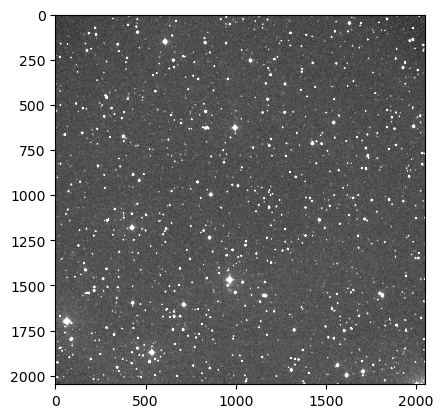

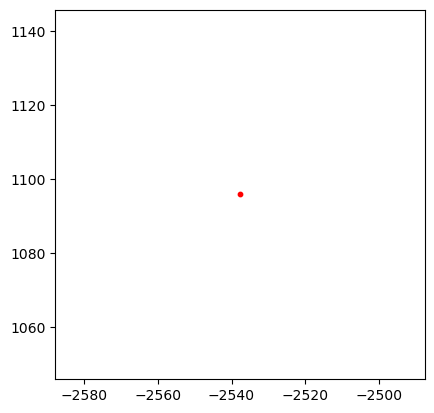

In [8]:
ra = 7*15 + 28*0.25 + 05.0209456848*0.00416666666
print(ra)
dec = -54
print(dec)

folder = '//macdiarmid/ASTR211/2024_Lab_Files/Phot_Skills_Lab/' 
filename = 'TYC8555_338_1-0057_g_wcs.fits.gz'

hdu = fits.open(folder + filename)
header = hdu[0].header
data = hdu[0].data
hdu.close()

wcs = WCS(header)
x, y = wcs.all_world2pix(ra, dec, 0) # You can also use wcs.all_pix2world(x, y, 0) to convert from pixel to world coordinates

mjd = header['JD'] - 2400000.5

plt.figure()
plt.scatter(x, y, c = 'r', s = 10)
plt.imshow(data, vmin = np.nanpercentile(data, 5), vmax = np.nanpercentile(data, 99), cmap = 'gray')
plt.show()

plt.figure()
plt.scatter(x, y, c = 'r', s = 10)
plt.imshow(data, vmin = np.nanpercentile(data, 5), vmax = np.nanpercentile(data, 99), cmap = 'gray')
plt.xlim(x - 50, x + 50)
plt.ylim(y - 50, y + 50)
plt.show()


# Aperture Photometry on a Single Star

Aperture photometry is a common method of analysing targets or fields of targets. 

This is where you place a circle or "aperture" about the target to count all of the flux within the circle. We often use an outer annulus' to determine the noise and the signal.

Typically this is based on the Full-Width at Half Maximum (FWHM). The FWHM is the diameter in which an object appears half as bright as it does at its centre. The FWHM is primarily determined by two factors; the seeing (turbulence in the atmosphere) and the spatial resolution of the telescope.

We will explore the source extractor tool "DAOStarFinder" later on in the Lab.


## Task 2

- Look at the zoomed in image above.
- Find a value of the Full-Width at Half Maximum (fwhm) that you think optimises the light captured. Experiment with different values.
- There are two other radius values (r_inner, r_outer) that need to be set that generate a ring that contains no starlight. This ring, or annulus, will measure background flux.

In [4]:
fwhm = ??? # FWHM of the source in pixels, input your values


'''
Source Finding Tool. We will explore this later.
'''
mean, median, std = sigma_clipped_stats(data, sigma=3.0)  # Adjust sigma as needed

# Initialize DAOStarFinder with the background statistics
daofind = DAOStarFinder(fwhm=3.0, threshold=10.0*std)  # Adjust fwhm and threshold as needed
sources = daofind(data) # Find sources in the image

'''
Filtering sources so we only get our target
'''
fwhm = 2 # How far away from the source to look for other our coordinates
filtered_sources = sources[(np.abs(sources['xcentroid'] - x) <= fwhm) & (np.abs(sources['ycentroid'] - y) <= fwhm)]

positions = np.zeroes((len(filtered_sources), 2))
positions[:,0] = filtered_sources['xcentroid'].value
positions[:,1] = filtered_sources['ycentroid'].value

print(positions) # Print the filtered sources


'''
Aperture photometry tools
'''
aperture = CircularAperture(positions, r= fwhm)

# For this example we will ignore NaN values in the data. These create massive issues with the aperture photometry, so we will mask them out.
# This is not typically necessary for most astronomical images, however, this will never harm you to include these lines.
# I have been burned too many times.
nan_mask = ~np.isfinite(data) # Create mask to exclude NaN pixels
masked_reference = np.ma.masked_array(data, mask=nan_mask) # Apply aperture photometry while ignoring NaNs

phot_table = aperture_photometry(masked_reference, aperture) # Perform aperture photometry

r_inner = fwhm * ??? # Set inner radii for annulus
r_outer = fwhm * ??? # Set outer radii for annulus
annulus_aperture = CircularAnnulus(positions, r_in= r_inner, r_out=r_outer) # Create an annulus for background subtractions

flux = phot_table['aperture_sum'][0] # Extract the flux from the photometry table

print(flux)

# Plotting to visualise the aperture and annulus
plt.figure()
plt.imshow(data, vmin = np.nanpercentile(data, 2), vmax = np.nanpercentile(data, 99.8), cmap = 'gray')
plt.scatter(x, y, c = 'r', s = 10) # RA and DEC coordinates from WCS
plt.scatter(positions[:,0], positions[:,1], c = 'y', s = 25, marker = '*', edgecolors='k', linewidths=0.5) # Plot the source
aperture.plot(color='red', lw=1.5) # Plot the aperture
annulus_aperture.plot(color='yellow', lw=1.5) # Plot the annulus
plt.xlim(x - 50, x + 50)
plt.ylim(y - 50, y + 50)
plt.show()

SyntaxError: invalid syntax (963831725.py, line 1)

## Task 3

Using the skills from the "Understanding Python" module and from PHYS285 we will briefly explore how to choose the best aperture size.

- Take a row slice through the centre of the star
- Limit this column to $\pm$ 20 around the maximum of the star
- Fit a 1d gaussian to this slice using the "curve_fit" function you have used in PHYS285
- Plot this.

Doing this modelling is a 1st order method into learning Point-Spread Function (PSF) Photometry. For more on PSF photometry look at the Additional Resource section at the end of the tutorial.

The FWHM can be calculated from the standard devation of a gaussian using: $FWHM = 2\sqrt{2\ln{2}}\sigma \approx 2.355 \sigma$
- How does the FWHM you chose compare to the plot? What value do you think is the best now?
- What do you think the consequences are for overestimating the radius? Underestimating?

Copy the code from above and modify it with the new aperture radius.


In [ ]:
def gaussian(x, a, mu, sigma, c):
    # A gaussian. It takes in x values, the amplitude, the mean, the standard deviation, and a constant. It returns the corresponding y values.
    y = a * np.exp(-(x - mu)**2 / (2 * sigma**2)) + c
    return y



### Error in Aperture Photometry

Below is a code to calculate the Signal to Noise Ratio (SNR) and error in the flux. Because we are signal dominated we can simplify the equation to only consider general noise and not include dark current, readout noise and more.

What is the code doing? How did we calculate the error?

How good is the signal for our target?

In [ ]:
# Signal to Noise

aperstats = ApertureStats(data, annulus_aperture)

aperstats_std = aperstats.std
aperture_area = aperture.area

main_error = (aperstats_std * aperture_area)[0]

snr = flux / main_error


print('Flux:', flux, 'Error:', main_error)
print('SNR:', snr)

### Magnitudes

We will now use this information to calculate the magnitude of the target. There are a few things to consider. Recall the equation for magnitude:

$$m_X^{} = -2.5 {\rm log}_{10}(f) + {\rm ZP},$$
where $X$ represents the filter, $f$ is the total flux and ${\rm ZP}$ is the zeropoint. The zeropoint is dependent on the observing conditions, filter, noise, sensitivity and more. "Pouakai" the reduction pipeline that reduced the images you are using uses a package "calibrimbore" to standardise the filters to either Skymapper or Panstarrs photometry for AB magnitude calibration. (Refer to notes or photometry experts if you want to know more about the differences between AB, SB, and Vega Mag.). 

For most pipeline's reduced images the zeropoint can be found in the header. Most of "Pouakai's" images are scaled such that the zeropoint is always 25.

- Use the flux to calculate the magnitude.
- Use the "mag_error" function to calculate the error in the magnitude.
- Compare this value to what SIMBAD states, how does it differ?

In [ ]:
def mag_error(f, f_error, zp_error):
    delta_f_term = 2.5/np.log(10) * (f_error/f)
    delta_zp_term = zp_error
    
    return np.sqrt(delta_f_term**2 + delta_zp_term**2)

# Multiple Images of a Single Star
If we take many images over time of a star, we can make a lightcurve.
## Task 4

Your task is to use a purely aperture approach (no PSF) to process all of the files for the star "TYC 8555-338-1". This will require you to choose some aperture size. A slow code should take a minute to run. To loop through the files, revise the methods from Lab 1. The macdiarmid server folder path is ASTR211/2024_Lab_Files/Phot_Skills_Lab/.

This data was originally collected as the TESSReduce pipeline (for analysis of transient-like objects in the TESS space telescope) found this star to be possibly variable, despite it never being labelled as one in any database.

- Process all of the data and gather the flux, flux error, magnitude, magnitude error.
- Plot the magnitude with respect to time in Modified Julian Date along the x-axis. 

Is this star a variable star? Why do you think so? Discuss with a tutor

# Multiple Stars in a field

Previously we were looking at a single target in a field, however, we often want to analyse multiple targets in a single field.

We are going to look more into the source extraction tool before continuing.

Below is a method of source finding/extraction. The "threshold" parameter is the minimum counts the target must be above to be considered a "source". The "fwhm" parameter is an estimate of the size for the targets, this means hotpixels and extended patterns can get ignored.

## Task 5

- Explore with the "threshold" parameter. How does this change detection levels (i.e. how many stars it finds)?
- Explore with the "fwhm" parameter. How does this change detection levels (i.e. how many stars it finds)?

- Choose a "fwhm" and "threshold" that you think optimises the detection for semi-bright sources.

In [ ]:
data_copy = deepcopy(data)

mean, median, std = sigma_clipped_stats(data_copy, sigma=3.0)  # Adjust sigma as needed
daofind = DAOStarFinder(fwhm = 3.5, threshold = 20.0*std)  # Adjust fwhm and threshold as needed
sources = daofind(data_copy) # Find sources in the image
xs = sources['xcentroid']
ys = sources['ycentroid']

plt.figure()
plt.imshow(data_copy, vmin = np.nanpercentile(data_copy, 2), vmax = np.nanpercentile(data_copy, 99))
plt.scatter(xs, ys, c = 'r', s = 10)
plt.show()

## Task 6
Now change your aperture code from Task 2 and using the list of targets from Task 5 to process all of the stars in a single image, now find the flux, flux error, magnitude, magnitude error, and SNR.

What is needed to create a colour magnitude diagram now? Discuss this with a tutor

A slow version of the code should take approx. 1 minute, a semi-fast version takes under two seconds.

# Multiple Stars in a Crowded Field
We can observe many stars in a field that are nearby each other to make measurements, such as an Colour Magnitude Diagram (CMD)
## Task 7
Use the same code with new parameters to analyse the flux, flux error, magnitude, magnitude error in a crowded field, with the goal of creating a colour-magnitude diagram.

This file can be found in the zip folder from the LEARN page titled: "Lab2 Part 1 and 2 - Data"

You will need to process both files in the different filters using the same source positions for both images (but different to the sparse field).